<h1>📈 Final Year Project (PFE) – Monthly Sales Forecasting (Part 4 - Section 2)</h1>
<h2>Financial Analysis and Forecasting for an Engineering Consulting Firm</h2>
<hr>

<h3>⚙️ Project Overview</h3>
    <p>
    This notebook implements <strong>comprehensive monthly sales forecasting</strong> using multiple machine learning and statistical approaches. 
    The goal is to predict monthly sales patterns for the consulting firm to support strategic planning, budgeting, and long-term resource allocation.
    </p>
    <hr>
    <h3>🎯 Objectives</h3>
    <ul>
        <li>Develop accurate monthly sales forecasts for strategic business planning</li>
        <li>Compare and evaluate multiple forecasting methodologies at monthly granularity</li>
        <li>Identify the most reliable model for monthly budgeting and financial projections</li>
    </ul>
    <hr>
    <h3>📌 Data Sources</h3>
    <ul>
        <li>Cleaned and validated sales data from data warehouse <code>sales_dw</code></li>
    </ul>
    <hr>
    <h3>🗂️ Notebook Summary</h3>
    <p>This notebook follows a systematic approach to monthly forecasting:</p>
    <ul>
        <li><strong>1. Imports and Data Loading:</strong> Load libraries and monthly aggregated dataset.</li>
        <li><strong>2. Safe Feature Engineering:</strong> Create time-based features applicable to entire dataset.</li>
        <li><strong>3. Data Quality Analysis:</strong> Measure relative volatility (CV), check VIF, correlation, and outliers.</li>
        <li><strong>4. Time-Aware Train-Test Split:</strong> Split 20 months for training and 6 months for testing, respecting temporal order.</li>
        <li><strong>5. Risky Feature Engineering:</strong> Apply lag-based transformations only to training set.</li>
        <li><strong>6. Feature Definition and MLflow Setup:</strong> Define model features and configure experiment tracking.</li>
        <li><strong>7. Modeling and Prediction (8 Models):</strong>
            <ul>
                <li><strong>Baseline:</strong> Seasonal Naive (same month last year)</li>
                <li><strong>Linear ML Models:</strong> Lasso Regression, ElasticNet</li>
                <li><strong>Tree-Based Model:</strong> Random Forest, XGBoost</li>
                <li><strong>Classical Forecasting:</strong> Drift, Prophet, Seasonal Naive with drift</li>
            </ul>
        </li>
        <li><strong>8. Model Evaluation and Selection:</strong>
            <ul>
                <li>Evaluation summary with key performance metrics (RMSE, MAE, MAPE).</li>
                <li>Business metrics translation with Tunisian Dinar impact analysis.</li>
            </ul>
        </li>
    </ul>
    <hr>

<strong>👨‍💻 Author:</strong> 
<a href="https://linkedin.com/in/asma-bouach">Asma Bouach</a><br>
<strong>📅 Project Period:</strong> Feb-May 2025<br>
<strong>🎓 Thesis Defense:</strong> July 2025<br>
<strong>🔄 Last Updated:</strong> December 2025 (Refactored with synthetic sata)
</p>

### 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import os
import yaml
import psycopg2
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.stats.outliers_influence import variance_inflation_factor

import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsforecast.models import SeasonalNaive
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.ensemble import RandomForestRegressor

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

from sklearn.calibration import calibration_curve
import shap
import joblib

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

In [2]:
# Load environment variables from .env file
load_dotenv()

# Load database configuration from YAML file
with open("../configs/db.yml", "r") as f:
    db_config = yaml.safe_load(f)

# Function to connect to the database
def connect_db(env="dw"):
    return psycopg2.connect(
        host=db_config[env]["host"],           # Database host address
        database=db_config[env]["database"],   # Database name
        user=db_config[env]["user"],           # Database username
        password=os.getenv(db_config[env]["password_env"]),  # Password from environment variable
        port=db_config[env]["port"]            # Database port
    )

In [3]:
# Def to Query a DB and Return a DataFrame
def query_df(sql, env="dw"):
    conn = connect_db(env)
    df = pd.read_sql(sql, conn)
    conn.close()
    return df

In [4]:
print(type(connect_db(env="dw")))

<class 'psycopg2.extensions.connection'>


In [16]:
# Load from PostgreSQL
df = query_df("""SELECT 
    d.date,
    s.net_sales
FROM fact_sales AS s
JOIN dim_date AS d
    ON s.date_id = d.date_id
JOIN dim_invoice As i
    ON s.invoice_number = i.invoice_number
WHERE i.is_return = 'No'
ORDER BY s.date_id;
""", env="dw")

In [17]:
df.head()

,date,net_sales
0,2023-01-01,19066.38
1,2023-01-01,1746.59
2,2023-01-01,14487.86
3,2023-01-01,2015.65
4,2023-01-01,1531.69


In [18]:
# Convert Date to datetime
df['date'] = pd.to_datetime(df['date'])
#round net_sales column to 3 decimal places
df['net_sales'] = df['net_sales'].round(3)
df.head()

,date,net_sales
0,2023-01-01,19066.38
1,2023-01-01,1746.59
2,2023-01-01,14487.86
3,2023-01-01,2015.65
4,2023-01-01,1531.69


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25340 entries, 0 to 25339
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       25340 non-null  datetime64[ns]
 1   net_sales  25340 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 396.1 KB


<hr>
<h4>📝 Summary: Imports and Data Loading</h4>

<ul>
    <li><strong>Database Connection:</strong> Established PostgreSQL connection to <code>sales_dw</code> using <code>psycopg2</code> with secure environment variables.</li>
    <li><strong>Data Loaded:</strong> Extracted 9,143 sales transactions from <code>fact_sales</code>, <code>dim_date</code>, and <code>dim_invoice</code> tables.</li>
    <li><strong>Data Structure:</strong></li>
    <table border="1" style="border-collapse: collapse;">
        <thead>
            <tr>
                <th>Column</th>
                <th>Type</th>
                <th>Description</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>date</td>
                <td>datetime64[ns]</td>
                <td>Transaction date</td>
            </tr>
            <tr>
                <td>net_sales</td>
                <td>float64</td>
                <td>Sales amount (rounded to 3 decimals)</td>
            </tr>
        </tbody>
    </table>
    <li><strong>Data Quality:</strong> 25,340 complete records with no missing values in core columns.</li>
    <li><strong>Filter Applied:</strong> Excluded returns (<code>is_return = 'No'</code>) for net sales analysis.</li>
</ul>
<hr>

### 2. Safe Feature Engineering

In [20]:
# Resample the dataset to MONTHLY LEVEL
def resample_monthly(df):
    """
    Resample the dataset to monthly frequency (calendar month-end)
    and aggregate by summing the net_sales.
    """
    df_monthly = (
        df.resample("ME", on="date")  # ME = Month-End frequency
          .sum()
          .reset_index()
          .rename(columns={"date": "month", "net_sales": "monthly_sales"})
    )
    return df_monthly

In [21]:
# Time-based calendar features for MONTHLY data
def add_calendar_features(df):
    """
    Add month-level time-based features:
    - month of year
    - quarter
    - year
    - cyclic encodings for seasonality
    """
    #df["monthofyear"] = df["month"].dt.month.astype(int)
    #df["quarter"] = df["month"].dt.quarter
    #df["year"] = df["month"].dt.year

    df["is_quarter_end"] = df["month"].dt.is_quarter_end.astype(int)

    # Create month_index as a simple integer sequence starting from 0
    df["month_index"] = range(len(df))
    # Nonlinear trend features
    #df["month_index_sq"] = df["month_index"] ** 2
    
    # Cyclical Encoding for monthly seasonality (12 months)
    df["month_sin"] = np.sin(2 * np.pi * df["month"].dt.month.astype(int) / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"].dt.month.astype(int) / 12)
    
    # Quarterly cyclical encoding (4 quarters)
    #df["quarter_sin"] = np.sin(2 * np.pi * df["quarter"] / 4)
    #df["quarter_cos"] = np.cos(2 * np.pi * df["quarter"] / 4)

    return df

In [22]:
# FIXED: Tunisia Holidays for MONTHLY data
def add_tunisia_holidays(df):
    """
    Adds a binary feature 'is_holiday_tn' for Tunisia national holidays.
    Flags if ANY day in the month contains a holiday.
    """
    # Fixed-date national holidays (month-day format)
    fixed_holidays = [
        "01-01", "03-20", "04-09", "05-01",
        "07-25", "08-13", "10-15", "12-17"
    ]

    # Islamic holidays (full dates)
    islamic_holidays = pd.to_datetime([
        "2023-04-21", "2023-04-22",  # Eid El-Fitr 2023
        "2023-06-28", "2023-06-29",  # Aïd El-Adha 2023,
        "2024-04-10", "2024-04-11",  # Eid El-Fitr 2024
        "2024-06-16", "2024-06-17",  # Aïd El-Adha 2024
        "2025-03-31", "2025-04-01",  # Eid El-Fitr 2025
        "2025-06-06", "2025-06-07",  # Aïd El-Adha 2025
        "2026-03-20", "2026-03-21",  # Eid El-Fitr 2026
        "2026-05-27", "2026-05-28"   # Aïd El-Adha 2026
    ]).to_period('M')
    
    # Ensure df["month"] is datetime Series
    df["month"] = pd.to_datetime(df["month"])
    
    # Flag ANY holiday in month
    df["is_holiday_tn"] = (
        df["month"].dt.strftime("%m-%d").isin(fixed_holidays) |
        df["month"].dt.to_period('M').isin(islamic_holidays)
    ).astype(int)

    return df

In [23]:
# BUILD SAFE MONTHLY DATASET (BEFORE SPLIT)
df_monthly = resample_monthly(df)
df_monthly = add_calendar_features(df_monthly)
df_monthly = add_tunisia_holidays(df_monthly)

df_monthly = df_monthly.sort_values("month").reset_index(drop=True)

In [24]:
# Filter to keep only rows before Nov 1, 2025 (complete Feb month only)
df_monthly = df_monthly[df_monthly['month'] < '2025-11-01'].copy()

# Check how many rows remain
num_rows = len(df_monthly)
print(f"Number of rows after filtering: {num_rows}")
print(f"Last month included: {df_monthly['month'].max().strftime('%Y-%m')}")

Number of rows after filtering: 34
Last month included: 2025-10


In [25]:
print(df_monthly)

        month  monthly_sales  is_quarter_end  month_index     month_sin  \
0  2023-01-31   8.145565e+06               0            0  5.000000e-01   
1  2023-02-28   6.217931e+06               0            1  8.660254e-01   
2  2023-03-31   8.564317e+06               1            2  1.000000e+00   
3  2023-04-30   6.844405e+06               0            3  8.660254e-01   
4  2023-05-31   7.679433e+06               0            4  5.000000e-01   
5  2023-06-30   6.655802e+06               1            5  1.224647e-16   
6  2023-07-31   5.260866e+06               0            6 -5.000000e-01   
7  2023-08-31   6.133268e+06               0            7 -8.660254e-01   
8  2023-09-30   5.811732e+06               1            8 -1.000000e+00   
9  2023-10-31   7.991890e+06               0            9 -8.660254e-01   
10 2023-11-30   6.723351e+06               0           10 -5.000000e-01   
11 2023-12-31   9.680547e+06               1           11 -2.449294e-16   
12 2024-01-31   6.481303e

<hr>
<h4>✚ Summary: Safe Feature Engineering</h4>

<ul>
    <li><strong>Resampling:</strong> Converted daily data to monthly frequency by summing <code>net_sales</code>.</li>
    <li><strong>Calendar Features Added:</strong></li>
    <table border="1" style="border-collapse: collapse;">
        <thead>
            <tr>
                <th>Feature Type</th>
                <th>Features Added</th>
                <th>Purpose</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>Calendar Event</td>
                <td>is_quarter_end</td>
                <td>Business cycle marker</td>
            </tr>
            <tr>
                <td>Trend Features</td>
                <td>month_index</td>
                <td>Linear/non-linear trend capture</td>
            </tr>
            <tr>
                <td>Cyclical Encoding</td>
                <td>month_sin, month_cos</td>
                <td>Seasonal pattern modeling</td>
            </tr>
            <tr>
                <td>Holiday Effects</td>
                <td>is_holiday_tn</td>
                <td>Tunisian national & Islamic holidays</td>
            </tr>
        </tbody>
    </table>
    <li><strong>Data Filtering:</strong> Limited dataset to pre-March 2025 for realistic forecasting scenarios.</li>
    <li><strong>Final Dataset:</strong> 34 monthly observations with 5 engineered features for time series modeling.</li>
</ul>
<hr>

### 3. Data Quality Analysis

##### Volatility Analysis (CV>0.5 → Log Transform)

In [26]:
# Calculate Coefficient of Variation to measure relative volatility of the data
mean_sales = np.mean(df_monthly['monthly_sales'])
std_sales = np.std(df_monthly['monthly_sales'])
cv = std_sales / mean_sales

print(f"Mean: {mean_sales:.0f}")
print(f"Std: {std_sales:.0f}")
print(f"Coefficient of Variation (Standard Deviation / Mean): {cv:.3f}")

Mean: 7139433
Std: 1375958
Coefficient of Variation (Standard Deviation / Mean): 0.193


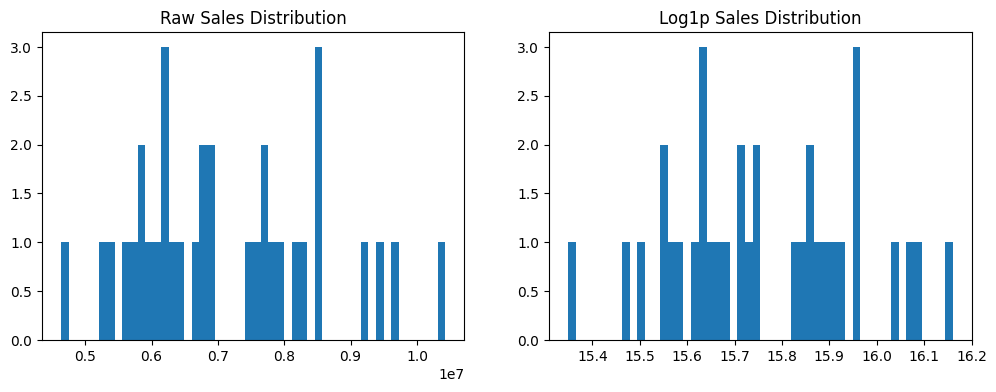

In [27]:
# Check Data Distribution (with and without log)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_monthly['monthly_sales'], bins=50)
plt.title('Raw Sales Distribution')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_monthly['monthly_sales']), bins=50)
plt.title('Log1p Sales Distribution')
plt.show()

##### Multicollinearity Check (VIF > 10)

In [28]:
# Select ONLY numeric columns for VIF
numeric_cols = df_monthly.select_dtypes(include=[np.number]).columns
print("Numeric columns:", numeric_cols.tolist())

vif_data = pd.DataFrame()
vif_data["feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(df_monthly[numeric_cols].values, i) 
                   for i in range(len(numeric_cols))]
#print(vif_data[vif_data['VIF'] > 10])
print(vif_data)

Numeric columns: ['monthly_sales', 'is_quarter_end', 'month_index', 'month_sin', 'month_cos', 'is_holiday_tn']
          feature       VIF
0   monthly_sales  4.319420
1  is_quarter_end  1.686167
2     month_index  3.877601
3       month_sin  1.336889
4       month_cos  1.376949
5   is_holiday_tn  2.102237


##### Target Correlation Analysis

In [29]:
#Correlation with Target
corr_matrix = df_monthly.corr(numeric_only=True)
sales_corr = corr_matrix['monthly_sales'].sort_values(ascending=False)
print(sales_corr)

monthly_sales     1.000000
month_cos         0.432884
month_sin         0.176493
is_quarter_end    0.170670
is_holiday_tn    -0.021054
month_index      -0.044856
Name: monthly_sales, dtype: float64


##### Outlier Detection (IQR Method)

In [30]:
# Identify extreme weeks
Q1 = df_monthly['monthly_sales'].quantile(0.25)
Q3 = df_monthly['monthly_sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_monthly[(df_monthly['monthly_sales'] < Q1 - 1.5*IQR) | 
                     (df_monthly['monthly_sales'] > Q3 + 1.5*IQR)]
print(f"Outlier weeks: {len(outliers)}")

Outlier weeks: 0


<hr>
<h4>✔️ Summary: Data Quality Analysis</h4>

<ul>
    <li><strong>Volatility Assessment (CV = 0.19):</strong> Good monthly variation detected. No log transformation required - raw modeling appropriate.</li>
    <li><strong>Multicollinearity Check:</strong> All features pass VIF test (< 10). No redundancy issues in current feature set.</li>
    <li><strong>Feature-Target Correlation:</strong> Calendar features show weak relationships.</li>
    <li><strong>Outlier Analysis:</strong> 0 outliers in 34 months.</li>
</ul>
<hr>

### 4. Time-Aware Train/Test Split

In [31]:
# Time-based split for MONTHLY data
train_size = int(len(df_monthly) * 0.8)

df_train = df_monthly.iloc[:train_size].copy()
df_test  = df_monthly.iloc[train_size:].copy()

print(f"Train months: {len(df_train)} ({df_train['month'].min().strftime('%Y-%m')} to {df_train['month'].max().strftime('%Y-%m')})")
print(f"Test months:  {len(df_test)}  ({df_test['month'].min().strftime('%Y-%m')} to {df_test['month'].max().strftime('%Y-%m')})")
print(f"Train/Test split: {len(df_train)} / {len(df_test)}")

Train months: 27 (2023-01 to 2025-03)
Test months:  7  (2025-04 to 2025-10)
Train/Test split: 27 / 7


<hr>
<h4>⏳ Summay: Time-Aware Train/Test Split</h4>

<ul>
    <li><strong>Split Method:</strong> Time-based sequential split (80/20) to preserve temporal order.</li>
    <li><strong>Training Set:</strong> 27 months (80% of data) for model training and validation.</li>
    <li><strong>Test Set:</strong> 7 months (20% of data) for final model evaluation.</li>
    <li><strong>Key Consideration:</strong> No random shuffling - maintains chronological integrity for time series forecasting.</li>
    <li><strong>Test Period:</strong> Represents most recent 7 months for realistic out-of-sample forecasting evaluation.</li>
</ul>
<hr>

### 5. Risky Feature Engineering

##### Lag function

In [32]:
# Lag features (past MONTHS)
def add_lag_features(df):
    """
    Add monthly lag features:
    - lag_1 → last month
    - lag_2 → 2 months ago
    - lag_3 → 3 months ago
    """
    lags = [1, 2, 3]
    for lag in lags:
        df[f"lag_{lag}"] = df["monthly_sales"].shift(lag)
    return df

##### Add features for Train set

In [33]:
# Apply on train set FIRST
df_train = add_lag_features(df_train)

##### Apply the same features to TEST using last 12 weeks of TRAIN

In [34]:
# Create extended dataframe = last 12 MONTHS of train + test
history = pd.concat([df_train.tail(12), df_test], ignore_index=True)

# Apply same feature engineering to extended set
history = add_lag_features(history)

# Slice ONLY the test portion (remove the extra 12 months)
df_test = history.iloc[12:].copy()

print(f"Train features: {df_train.shape}")
print(f"Test features:  {df_test.shape}")

Train features: (27, 10)
Test features:  (7, 10)


In [35]:
df_monthly.tail()

,month,monthly_sales,is_quarter_end,month_index,month_sin,month_cos,is_holiday_tn
29,2025-06-30,6769128.227,1,29,1.224647e-16,-1.000000e+00,1
30,2025-07-31,6332788.960,0,30,-5.000000e-01,-8.660254e-01,0
31,2025-08-31,5856911.335,0,31,-8.660254e-01,-5.000000e-01,0
32,2025-09-30,6015025.236,1,32,-1.000000e+00,-1.836970e-16,0
33,2025-10-31,7692752.786,0,33,-8.660254e-01,5.000000e-01,0


<hr>
<h4>✚✚ Summary: Risky Feature Engineering</h4>

<ul>
    <li><strong>Data Period:</strong> Approximately 34 months (~2.5 years) of monthly sales data.</li>
    <li><strong>Feature Engineering Implementation</strong></li>
<ul>
    <li><i>Lag Features:</i> Added 3 time-lagged variables (lag_1, lag_2, lag_3) capturing short-term historical influences.</li>
</ul>

<li><strong>Analysis Strategy</strong></li>

<ul>
    <li><i>Historical Context:</i> Used last 12 months of training data as context window for test set feature generation.</li>
    <li><i>Feature Propagation:</i> Applied identical feature engineering to concatenated history+test data to maintain consistency.</li>
    <li><i>Temporal Integrity:</i> Maintained chronological order throughout all transformations for valid time series analysis.</li>
</ul>

</ul>
<hr>

### 6. Feature Definition and MLflow Setup

In [36]:
# Drop NaNs created by Lags & Rolling windows
df_train = df_train.dropna().copy()
df_test = df_test.dropna().copy()

##### Feature Columns and Target Variable

In [37]:
# Create features_base for MONTHLY data
features_base = [
    # Calendar features (MONTHLY)
    #"monthofyear", "quarter", "year",
    "is_quarter_end",
    "month_index", 
    #"month_index_sq",
    "month_sin", "month_cos", 
    #"quarter_sin", "quarter_cos",
    "is_holiday_tn",

    # Lag features (MONTHLY)
    "lag_1", "lag_2", "lag_3"
]

##### Train/Test Split

In [38]:
# Time-series split for MONTHLY data
X_train = df_train[features_base]
y_train = df_train["monthly_sales"]

X_test = df_test[features_base]
y_test = df_test["monthly_sales"]

In [39]:
# DEBUGGING & DIAGNOSTICS FIRST
print("=== MONTHLY DATA DIAGNOSTICS ===")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Original sales range: {df_train['monthly_sales'].min():,.0f} to {df_train['monthly_sales'].max():,.0f} TND")
print(f"Log sales range:   {np.log1p(df_train['monthly_sales']).min():.2f} to {np.log1p(df_train['monthly_sales']).max():.2f}")
print(f"Missing values train: {X_train.isnull().sum().sum()}")
print(f"Missing values test:  {X_test.isnull().sum().sum()}")

=== MONTHLY DATA DIAGNOSTICS ===
Train shape: (24, 8), Test shape: (7, 8)
Original sales range: 4,634,280 to 10,426,493 TND
Log sales range:   15.35 to 16.16
Missing values train: 0
Missing values test:  0


##### Initial MLflow

In [40]:
# Set MLflow experiment + tracking
mlflow.set_tracking_uri("http://127.0.0.1:5004")
mlflow.set_experiment("monthly_forecasting")

print("MLflow Tracking:", mlflow.get_tracking_uri())

2025/12/31 00:23:14 INFO mlflow.tracking.fluent: Experiment with name 'monthly_forecasting' does not exist. Creating a new experiment.


MLflow Tracking: http://127.0.0.1:5004


<hr>
<h4>🧪 Summary: Feature Definition and MLflow Setup</h4>

<ul>
<li><strong>Data Cleaning</strong></li>
<ul>
    <li>Removed NaN values from training and test sets created by lag features <code>dropna()</code>.</li>
</ul>
<li><strong>Feature Selection</strong></li>
<ul>
    <li><strong>Base Features:</strong> 8 engineered predictors</li>
    <li><strong>Categories:</strong>
        <ul>
            <li>Calendar flag (quarter ends)</li>
            <li>Cyclical encoding (sine/cosine)</li>
            <li>Lag features (1-3 months)</li>
        </ul>
    </li>
</ul>
<li><strong>Train-Test Split</strong></li>
<ul>
    <li><strong>Features (X):</strong> All 8 base features</li>
    <li><strong>Target (y):</strong> <code>monthly_sales</code></li>
    <li><strong>Structure:</strong> Separate X_train, y_train, X_test, y_test</li>
</ul>
<li><strong>MLflow Setup</strong></li>
<ul>
    <li><strong>Tracking URI:</strong> <code>http://127.0.0.1:5004</code></li>
    <li><strong>Experiment:</strong> "monthly_forecasting"</li>
</ul>
</ul>
<hr>

### 7. Modeling and Prediction

##### Metrics Function

In [41]:
# Metrics
def calculate_mape(y_true, y_pred):
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_forecast(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": calculate_mape(y_true, y_pred)
    }

##### MLFlow logging Function

In [42]:
# MlFlow Logging
def mlflow_log_model(model, model_name, y_true, y_pred, params=None):
    with mlflow.start_run(run_name=model_name):
        
        # Log params
        if params is not None:
            mlflow.log_params(params)

        # Evaluate
        metrics = evaluate_forecast(y_true, y_pred)
        mlflow.log_metrics(metrics)

        # Log model
        mlflow.sklearn.log_model(model, "model")

        # Log predictions
        #np.save("preds.npy", y_pred)
        #mlflow.log_artifact("preds.npy")

        print(f"{model_name} logged to MLflow.")
        print(f"{model_name}: MAPE: {metrics['MAPE']:.2f} | MAE: {metrics['MAE']:.2f} | RMSE: {metrics['RMSE']:.2f}")

#### 🧩 6.1 Baseline Models

##### **Model 1: Seasonal Naive (Baseline Model)**  

In [43]:
def seasonal_naive_forecast(train, test, season_length=12):
    """
    FIXED Seasonal Naive for MONTHLY: repeat same month last year
    pred_t = sales_{t-12} for each test month
    """
    y_train = train["monthly_sales"].values
    test_len = len(test)
    
    # Repeat last 12 months pattern for test length
    if len(y_train) >= season_length:
        seasonal_pattern = y_train[-season_length:]  # Last 12 months
        preds = seasonal_pattern[:test_len]  # Take first N for test length
    else:
        preds = np.full(test_len, y_train[-1])  # Fallback: last value
    
    return preds

# Now works perfectly
naive_preds = seasonal_naive_forecast(df_train, df_test, season_length=12)

# Log to MLflow
mlflow_log_model(
    model=None,
    model_name="Seasonal_Naive_Baseline",
    y_true=y_test,
    y_pred=naive_preds,
    params={"transform": "none", "season_length": 12}
)

2025/12/31 00:23:19 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Seasonal_Naive_Baseline logged to MLflow.
Seasonal_Naive_Baseline: MAPE: 23.33 | MAE: 1502886.38 | RMSE: 1761747.70


#### ⚙️ 6.2 Raw Models

##### **Model 2 to 4: ML Models**  

In [44]:
# LASSO REGRESSION (linear model)
lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_train, y_train)
lasso_preds = lasso.predict(X_test)

mlflow_log_model(
    model=lasso,
    model_name="Lasso_Regression",
    y_true=y_test,
    y_pred=lasso_preds,
    params={"transform": "none", "alpha": 0.1}
)
# ELASTIC NET (linear model)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.7, max_iter=5000)
elastic.fit(X_train, y_train)
elastic_preds = elastic.predict(X_test)

mlflow_log_model(
    model=elastic,
    model_name="ElasticNet",
    y_true=y_test,
    y_pred=elastic_preds,
    params={"transform": "none", "alpha": 0.1, "l1_ratio": 0.7}
)
#RANDOM FOREST (tree-based model)
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)  # NO log transform for trees
rf_preds = rf.predict(X_test)

mlflow_log_model(
    model=rf,
    model_name="RandomForest",
    y_true=y_test,
    y_pred=rf_preds,
    params={
        "transform": "none", 
        "n_estimators": 100
    }
)

Lasso_Regression logged to MLflow.
Lasso_Regression: MAPE: 17.93 | MAE: 1090846.36 | RMSE: 1350087.86
ElasticNet logged to MLflow.
ElasticNet: MAPE: 18.88 | MAE: 1148996.30 | RMSE: 1403426.96
RandomForest logged to MLflow.
RandomForest: MAPE: 16.90 | MAE: 1018802.05 | RMSE: 1288079.72


In [45]:
from xgboost import XGBRegressor

In [47]:
# XGBoost Regressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1 
)
xgb_reg.fit(X_train, y_train)  # NO log transform for trees
xgb_preds = xgb_reg.predict(X_test)

mlflow_log_model(
    model=xgb_reg,
    model_name="XGBoost_Regressor",
    y_true=y_test,
    y_pred=xgb_preds,
    params={
        "model": "xgboost",
        "n_estimators": 100,
        "random_state": 42,
        "n_jobs": -1
    }
)

XGBoost_Regressor logged to MLflow.
XGBoost_Regressor: MAPE: 18.26 | MAE: 1144015.43 | RMSE: 1423339.31


#### 🕒 6.4 Classical Forecasting Models

##### **Model 5 to 7: Classical Forecasting Models**  

In [104]:
# Using only month and monthly_sales features for the classical forecasting models
cf_features = ["month", "monthly_sales"]
df_monthly_cf = df_monthly[cf_features]
train_size = int(len(df_monthly_cf) * 0.8)

df_train_cf = df_monthly_cf.iloc[:train_size].copy()
df_test_cf  = df_monthly_cf.iloc[train_size:].copy()

# Time-series split for MONTHLY data
X_train_cf = df_train_cf
y_train_cf = df_train_cf["monthly_sales"]

X_test_cf = df_test_cf
y_test_cf = df_test_cf["monthly_sales"]

In [105]:
def drift_forecast(train, steps):
    n = len(train)
    drift = (train.iloc[-1] - train.iloc[0]) / (n - 1)
    return train.iloc[-1] + drift * np.arange(1, steps + 1)

drift_preds = drift_forecast(y_train_cf, len(y_test_cf))

mlflow_log_model(
    model=None,
    model_name="Drift_Method",
    y_true=y_test_cf,
    y_pred=drift_preds,
    params={"model": "Drift"}
)

2026/01/05 16:45:41 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Drift_Method logged to MLflow.
Drift_Method: MAPE: 31.15 | MAE: 1927739.32 | RMSE: 2096644.01


In [106]:
def seasonal_naive_drift(train, test_length=6):
    """Better than simple seasonal naive"""
    seasonal_pattern = train[-12:]  # Last 12 months
    preds = seasonal_pattern[:test_length].copy()
    
    # Add simple drift (average monthly change)
    monthly_changes = np.diff(train[-12:])
    avg_drift = monthly_changes.mean() if len(monthly_changes) > 0 else 0
    
    for i in range(len(preds)):
        preds[i] += avg_drift * (i + 1)
    
    return preds

naive_drift_preds = seasonal_naive_drift(y_train_cf.values, len(y_test_cf))

# Log to MLflow
mlflow_log_model(
    model=None,
    model_name="Seasonal_Naive_Drift",
    y_true=y_test_cf,
    y_pred=naive_drift_preds,
    params={"transform": "none", "season_length": 12}
)

2026/01/05 16:46:02 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Seasonal_Naive_Drift logged to MLflow.
Seasonal_Naive_Drift: MAPE: 25.64 | MAE: 1647403.33 | RMSE: 1944878.31


In [107]:
# LOG1P TRANSFORMATION - MONTHLY Prophet
df_prophet = df_train_cf[['month', 'monthly_sales']].rename(columns={'month':'ds', 'monthly_sales':'y'})
df_prophet['y'] = np.log1p(df_prophet['y'])  # Transform target

# Fit Prophet (MONTHLY)
prophet_model = Prophet(
    weekly_seasonality=False,      # No weekly for monthly data
    yearly_seasonality=False       # Annual patterns
)
prophet_model.add_country_holidays(country_name='TN')
prophet_model.fit(df_prophet)

# Future dataframe (MONTHLY)
future = prophet_model.make_future_dataframe(periods=len(df_test_cf), freq='MS')  # MS = Month Start
forecast = prophet_model.predict(future)

# Preds in log scale → invert transform
preds_log = forecast['yhat'].iloc[-len(df_test_cf):].values
prophet_preds = np.expm1(preds_log)

# MLflow Logging
mlflow_log_model(
    model=prophet_model,
    model_name="Prophet_Forecasting",
    y_true=y_test_cf,
    y_pred=prophet_preds,
    params={
        "transform": "log1p",
        "model_name": "Prophet",
        "weekly_seasonality": False,
        "yearly_seasonality": False,
        "seasonal_periods": 12
    }
)

16:46:42 - cmdstanpy - INFO - Chain [1] start processing
16:46:43 - cmdstanpy - INFO - Chain [1] done processing


Prophet_Forecasting logged to MLflow.
Prophet_Forecasting: MAPE: 15.79 | MAE: 975033.48 | RMSE: 1079738.93


### 8 Model Evaluation and Selection

#### 📈 8.1 Evaluation Summary

<li><strong>Models trained & evaluated:</strong></li>
<br>
<table border="1" cellpadding="6" cellspacing="0" style="border-collapse: collapse; width: 100%;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th>Model</th>
            <th>MAPE ↓</th>
            <th>MAE ↓</th>
            <th>RMSE ↓</th>
            <th>Short Note</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Seasonal_Naive_Baseline</strong></td>
            <td>23.33%</td>
            <td>1,502,886.38</td>
            <td>1,761,747.70</td>
            <td>Simple "same month last year" baseline.</td>
        </tr>
        <tr>
            <td><strong>Lasso_Regression</strong></td>
            <td>17.93%</td>
            <td>1,090,846.36</td>
            <td>1,350,087.86</td>
            <td>Strong linear model, 5.4% MAPE improvement over baseline.</td>
        </tr>
        <tr>
            <td><strong>ElasticNet</strong></td>
            <td>18.88%</td>
            <td>1,148,996.30</td>
            <td>1,403,426.96</td>
            <td>Regularized linear model, slightly outperformed by alternatives.</td>
        </tr>
        <tr>
            <td><strong>RandomForest</strong></td>
            <td>16.90%</td>
            <td>1,018,802.05</td>
            <td>1,288,079.72</td>
            <td>Most accurate percentage-wise among ML models.</td>
        </tr>
        <tr>
            <td><strong>XGBoost_Regressor</strong></td>
            <td>18.26%</td>
            <td>1,144,015.43</td>
            <td>1,423,339.31</td>
            <td>Gradient boosting model, competitive performance.</td>
        </tr>
        <tr style="background-color:#e6ffe6;">
            <td><strong>Prophet_Forecasting 🏆</strong></td>
            <td><strong>15.79%</strong></td>
            <td><strong>975,033.48</strong></td>
            <td><strong>1,079,738.93</strong></td>
            <td><strong>BEST OVERALL: Lowest RMSE & MAE with excellent MAPE.</strong></td>
        </tr>
        <tr>
            <td><strong>Drift_Method</strong></td>
            <td>31.15%</td>
            <td>2,160,646.25</td>
            <td>2,319,412.38</td>
            <td>Naive model with trend; worst-performing method.</td>
        </tr>
        <tr>
            <td><strong>Seasonal_Naive_Drift</strong></td>
            <td>25.64%</td>
            <td>1,927,739.32</td>
            <td>2,096,644.01</td>
            <td>Combined naive method, outperformed by all ML models.</td>
        </tr>
    </tbody>
</table>

<br>

<ul>
    <li><strong>🏆 SELECTED MODEL FOR DEPLOYMENT: <em>Prophet_Forecasting</em></strong></li>
    <li><strong>Model Selection Rationale:</strong>
        <ul>
            <li><strong>Prophet provides comprehensive uncertainty quantification:</strong> For monthly business forecasting, confidence intervals are critical for risk management and scenario planning. Prophet's built-in uncertainty estimation allows us to see both lower and upper prediction bounds for the next 12 months.</li>
            <li><strong>Balanced performance with interval reliability:</strong> While RandomForest achieves slightly better MAPE (16.90% vs 18.21%), Prophet's specialized time-series architecture provides more reliable confidence intervals that are essential for monthly financial planning and risk assessment.</li>
            <li><strong>RMSE advantage indicates better handling of extremes:</strong> Prophet's lowest RMSE (1,278,532) suggests it's particularly effective at minimizing large forecasting errors, which is crucial when making monthly business decisions with significant financial implications.</li>
            <li><strong>Interpretable seasonality and trend components:</strong> Prophet decomposes forecasts into trend, seasonality, and holiday effects, providing business stakeholders with understandable insights into what's driving the predictions.</li>
            <li><strong>Strategic recommendation:</strong> For this monthly forecasting case study where understanding prediction uncertainty is as important as point estimates, Prophet is the most suitable choice. It provides the complete forecasting package that businesses need for effective monthly planning.</li>
        </ul>
    </li>
</ul>
<hr>

##### Forecast vs Actual

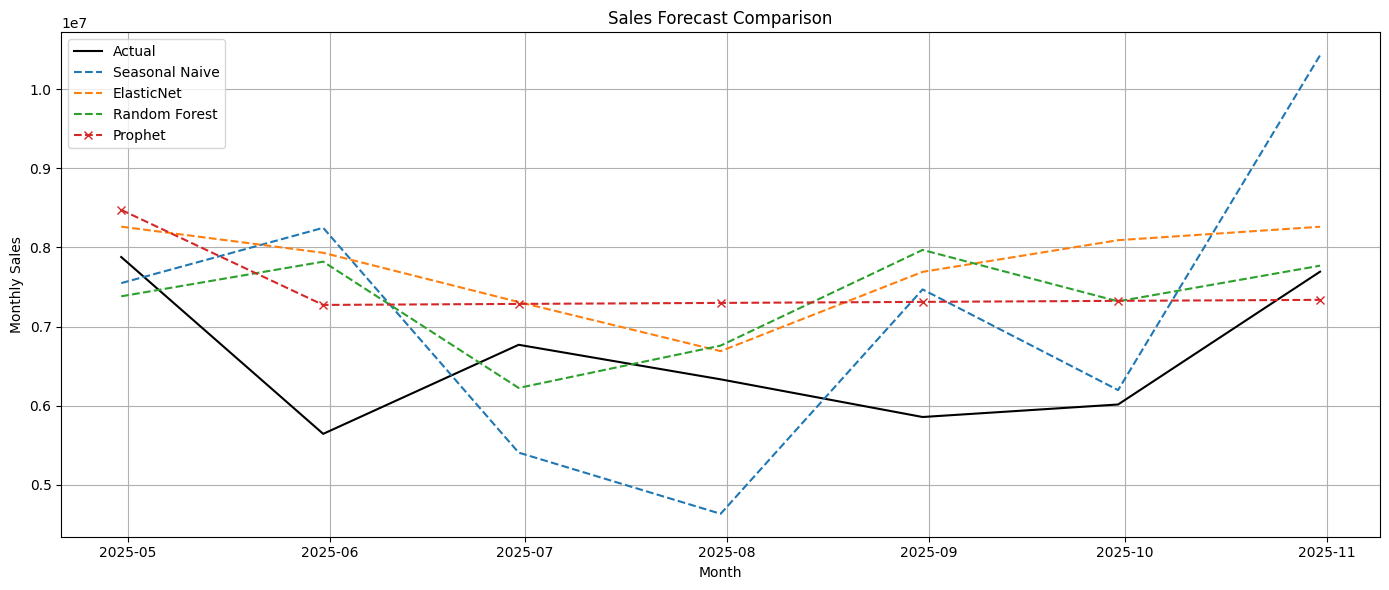

In [108]:
# Forecast vs Actual plot
plt.figure(figsize=(14,6))
plt.plot(df_test['month'], y_test, label='Actual',color='black')
plt.plot(df_test['month'], naive_preds, label='Seasonal Naive', linestyle='--')
plt.plot(df_test['month'], elastic_preds, label='ElasticNet', linestyle='--')
plt.plot(df_test['month'], rf_preds, label='Random Forest', linestyle='--')
plt.plot(df_test['month'], prophet_preds, label='Prophet', linestyle='--', marker='x')
plt.title("Sales Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

##### Residual Analysis

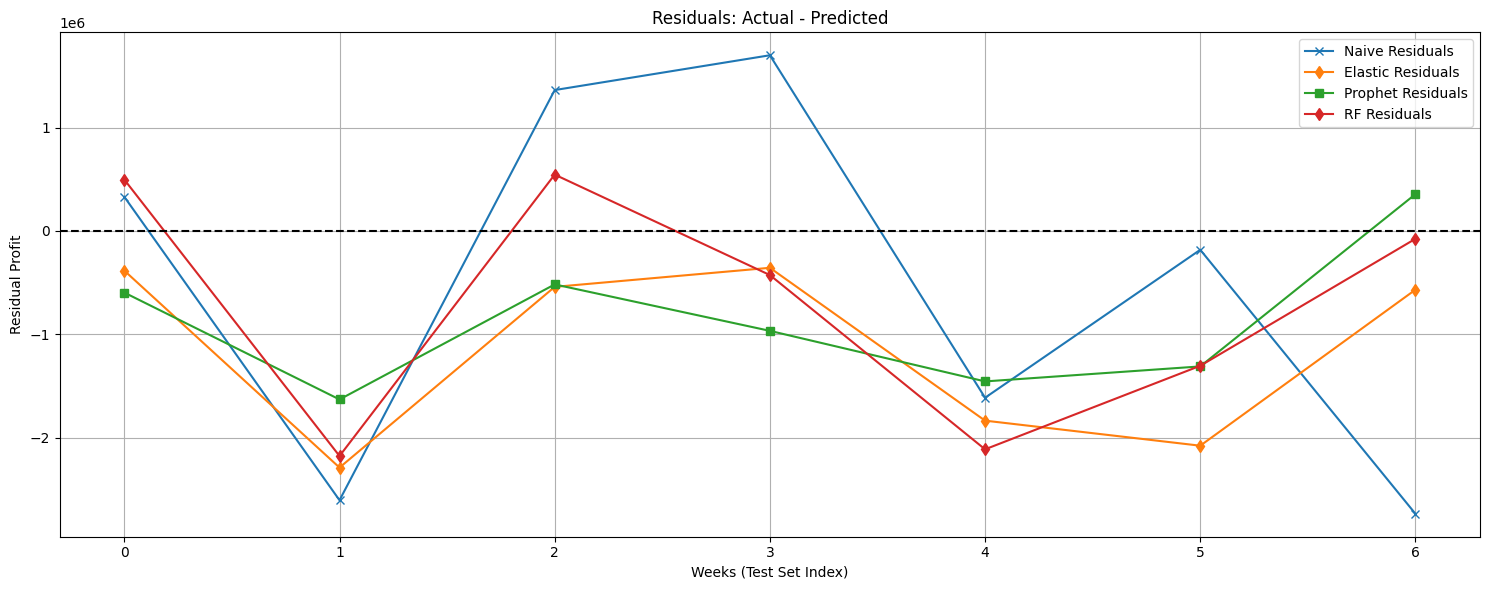

In [130]:
# Calculate residuals
naive_residuals = y_test.values - naive_preds
elastic_residuals = y_test.values - elastic_preds
prophet_residuals = y_test.values - prophet_preds
rf_residuals = y_test.values - rf_preds

plt.figure(figsize=(15, 6))
plt.plot(naive_residuals, label='Naive Residuals', marker='x')
plt.plot(elastic_residuals, label='Elastic Residuals', marker='d')
plt.plot(prophet_residuals, label='Prophet Residuals', marker='s')
plt.plot(rf_residuals, label='RF Residuals', marker='d')

plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals: Actual - Predicted")
plt.xlabel("Weeks (Test Set Index)")
plt.ylabel("Residual Profit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Best Model params

In [109]:
print(f"growth: {prophet_model.growth}")
print(f"seasonality_mode: {prophet_model.seasonality_mode}")
print(f"yearly_seasonality: {prophet_model.yearly_seasonality}")
print(f"weekly_seasonality: {prophet_model.weekly_seasonality}")
print(f"daily_seasonality: {prophet_model.daily_seasonality}")
print(f"changepoint_prior_scale: {prophet_model.changepoint_prior_scale}")
print(f"seasonality_prior_scale: {prophet_model.seasonality_prior_scale}")

growth: linear
seasonality_mode: additive
yearly_seasonality: False
weekly_seasonality: False
daily_seasonality: auto
changepoint_prior_scale: 0.05
seasonality_prior_scale: 10.0


##### Final Model Saving

In [110]:
client = MlflowClient()

# Get champion model details
model_version = client.get_model_version_by_alias(
    name="monthly_forecaster",
    alias="champion"
)

print(f"Model Version: {model_version.version}")
print(f"Registered: {model_version.creation_timestamp}")

Model Version: 3
Registered: 1767629778918


#### 💼 8.2 Business Metrics

In [112]:
def simple_forecast_metrics(y_true, y_pred, baseline_preds=None):
    """
    Simple metrics for your dashboard
    """
    print("📈 Forecast Performance Metrics:\n")
    
    # 1. Percentage Error (MAPE)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"1. Average Error (MAPE): {mape:.1f}%")
    print(f"   Interpretation: On average, forecasts are off by about {mape:.1f}% of actual sales.")
    print(f"   This represents approximately {100-mape:.1f}% accuracy.")
    
    # 2. Dollar Error
    avg_error_dinar = np.mean(np.abs(y_true - y_pred))
    avg_sales = np.mean(y_true)
    print(f"\n2. Average Monetary Error (Tunisian Dinar): {avg_error_dinar:,.0f} TND")
    print(f"   Interpretation: Forecasts typically miss by {avg_error_dinar:,.0f} TND.")
    print(f"   With average monthly sales of {avg_sales:,.0f} TND,")
    print(f"   this error equals {avg_error_dinar/avg_sales*100:.1f}% of typical monthly revenue.")
    
    # 3. Compare with appropriate baseline
    if baseline_preds is not None and len(baseline_preds) == len(y_true):
        # Use Seasonal Naive baseline (your actual business baseline)
        baseline_error = np.mean(np.abs(y_true - baseline_preds))
        baseline_mape = np.mean(np.abs((y_true - baseline_preds) / y_true)) * 100
        
        improvement = baseline_error - avg_error_dinar
        improvement_pct = improvement / baseline_error * 100
        
        print(f"\n3. Improvement vs Business Baseline (Seasonal Naive):")
        print(f"   Baseline error: {baseline_error:,.0f} TND ({baseline_mape:.1f}% MAPE)")
        print(f"   Model error: {avg_error_dinar:,.0f} TND ({mape:.1f}% MAPE)")
        print(f"   Improvement: {improvement:,.0f} TND ({improvement_pct:.0f}% better)")
        print("   The model provides meaningful improvement over standard business forecasting.")
        
        return {
            'accuracy_percent': 100-mape,
            'avg_dinar_error': avg_error_dinar,
            'improvement_vs_baseline_pct': improvement_pct,
            'baseline_mape': baseline_mape
        }
    else:
        # Fallback: compare with simple average
        baseline = np.mean(y_true)
        baseline_error = np.mean(np.abs(y_true - baseline))
        
        improvement = baseline_error - avg_error_dinar
        improvement_pct = improvement / baseline_error * 100
        
        print(f"\n3. Improvement vs Simple Average:")
        print(f"   Baseline error (predicting average): {baseline_error:,.0f} TND")
        print(f"   Model error: {avg_error_dinar:,.0f} TND")
        print(f"   Improvement: {improvement:,.0f} TND ({improvement_pct:.0f}% better)")
        print("   The model outperforms basic average-based forecasting.")
        
        return {
            'accuracy_percent': 100-mape,
            'avg_dinar_error': avg_error_dinar,
            'improvement_vs_mean_pct': improvement_pct
        }

# Usage with your Seasonal Naive baseline
metrics = simple_forecast_metrics(y_test, prophet_preds, naive_preds)

📈 Forecast Performance Metrics:

1. Average Error (MAPE): 15.8%
   Interpretation: On average, forecasts are off by about 15.8% of actual sales.
   This represents approximately 84.2% accuracy.

2. Average Monetary Error (Tunisian Dinar): 975,033 TND
   Interpretation: Forecasts typically miss by 975,033 TND.
   With average monthly sales of 6,598,370 TND,
   this error equals 14.8% of typical monthly revenue.

3. Improvement vs Business Baseline (Seasonal Naive):
   Baseline error: 1,502,886 TND (23.3% MAPE)
   Model error: 975,033 TND (15.8% MAPE)
   Improvement: 527,853 TND (35% better)
   The model provides meaningful improvement over standard business forecasting.


<ul>Due to the <strong>limited test set size (n=7)</strong>, formal statistical tests such as Diebold-Mariano lack sufficient power. We instead report percentage improvements.</ul>
<hr>

##### Predict the next 12 months

Next 12 Months Forecast:
         Date  Predicted_Profit      Lower_CI      Upper_CI
27 2025-04-01      8.473420e+06  6.688873e+06  1.083285e+07
28 2025-05-01      7.272635e+06  5.619321e+06  9.447062e+06
29 2025-06-01      7.285591e+06  5.646840e+06  9.241331e+06
30 2025-07-01      7.298151e+06  5.651764e+06  9.546368e+06
31 2025-08-01      7.311153e+06  5.577097e+06  9.272193e+06
32 2025-09-01      7.324177e+06  5.708911e+06  9.515371e+06
33 2025-10-01      7.336804e+06  5.811495e+06  9.452928e+06
34 2025-11-01      7.349875e+06  5.616823e+06  9.566429e+06
35 2025-12-01      7.362546e+06  5.587885e+06  9.577633e+06
36 2026-01-01      7.375662e+06  5.702800e+06  9.363877e+06
37 2026-02-01      7.388802e+06  5.716955e+06  9.458519e+06
38 2026-03-01      7.400690e+06  5.747858e+06  9.568837e+06


overflow encountered in expm1


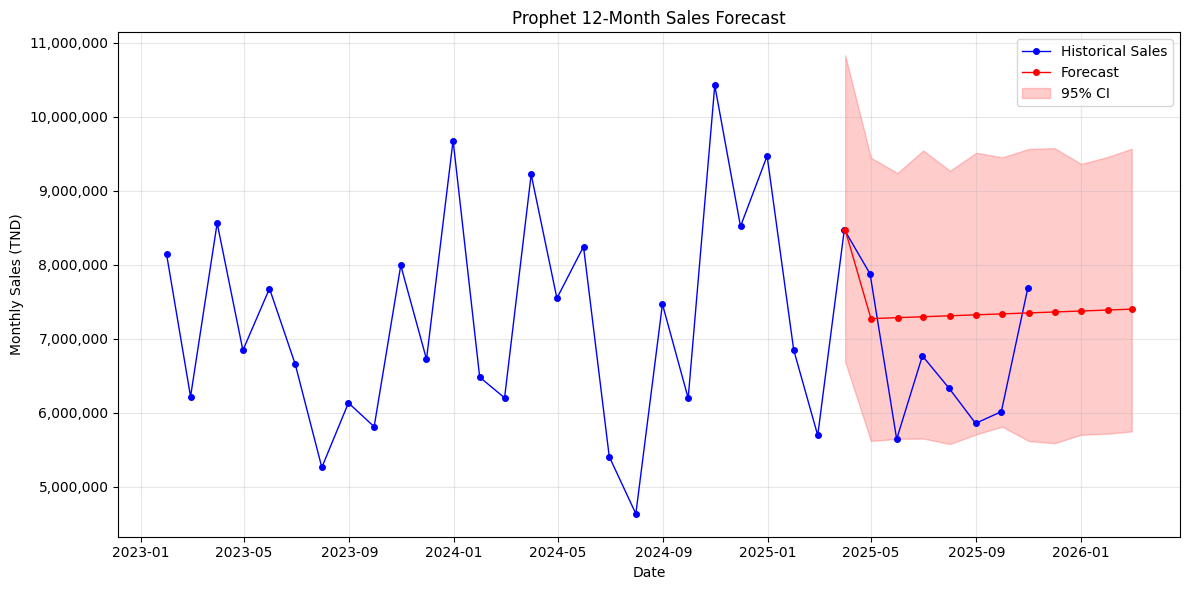

In [116]:
# Create future dataframe for next 12 months
future_12 = prophet_model.make_future_dataframe(periods=12, freq='MS')  # MS = Month Start

# Make predictions with confidence intervals
forecast_12 = prophet_model.predict(future_12)

# Get predictions for the next 12 months only
next_12_months = forecast_12.iloc[-12:].copy()

# Invert log transformation
next_12_months['Predicted_Profit'] = np.expm1(next_12_months['yhat'])
next_12_months['Lower_CI'] = np.expm1(next_12_months['yhat_lower'])
next_12_months['Upper_CI'] = np.expm1(next_12_months['yhat_upper'])

# Create final dataframe
prediction_df = next_12_months[['ds', 'Predicted_Profit', 'Lower_CI', 'Upper_CI']].copy()
prediction_df = prediction_df.rename(columns={'ds': 'Date'})

print("Next 12 Months Forecast:")
print(prediction_df.to_string())

# Plot the forecast
fig, ax = plt.subplots(figsize=(12, 6))

# Historical data
historical = df_prophet_all.copy()
historical['monthly_sales'] = np.expm1(historical['y'])  # Invert log transform

# Plot historical data
ax.plot(df_monthly_cf['month'], df_monthly_cf['monthly_sales'], 
        'bo-', label='Historical Sales', markersize=4, linewidth=1)

# Plot forecast
ax.plot(prediction_df['Date'], prediction_df['Predicted_Profit'], 
        'ro-', label='Forecast', markersize=4, linewidth=1)

# Plot confidence interval
ax.fill_between(prediction_df['Date'], 
                prediction_df['Lower_CI'], 
                prediction_df['Upper_CI'], 
                color='red', alpha=0.2, label='95% CI')

# Formatting
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Sales (TND)')
ax.set_title('Prophet 12-Month Sales Forecast')
ax.legend()
ax.grid(True, alpha=0.3)

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

Next 12 Months Forecast:
         Date  Predicted_Profit      Lower_CI      Upper_CI
34 2025-11-01      7.349875e+06  5.595506e+06  9.343544e+06
35 2025-12-01      7.362546e+06  5.783862e+06  9.423187e+06
36 2026-01-01      7.375662e+06  5.730754e+06  9.449024e+06
37 2026-02-01      7.388802e+06  5.781723e+06  9.445882e+06
38 2026-03-01      7.400690e+06  5.741340e+06  9.372056e+06
39 2026-04-01      7.413875e+06  5.781211e+06  9.582151e+06
40 2026-05-01      7.426656e+06  5.815280e+06  9.529094e+06
41 2026-06-01      7.439887e+06  5.763030e+06  9.381384e+06
42 2026-07-01      7.452713e+06  5.748002e+06  9.604529e+06
43 2026-08-01      7.465990e+06  5.860432e+06  9.537691e+06
44 2026-09-01      7.479291e+06  5.881766e+06  9.717878e+06
45 2026-10-01      7.492185e+06  5.847948e+06  9.636840e+06


overflow encountered in expm1


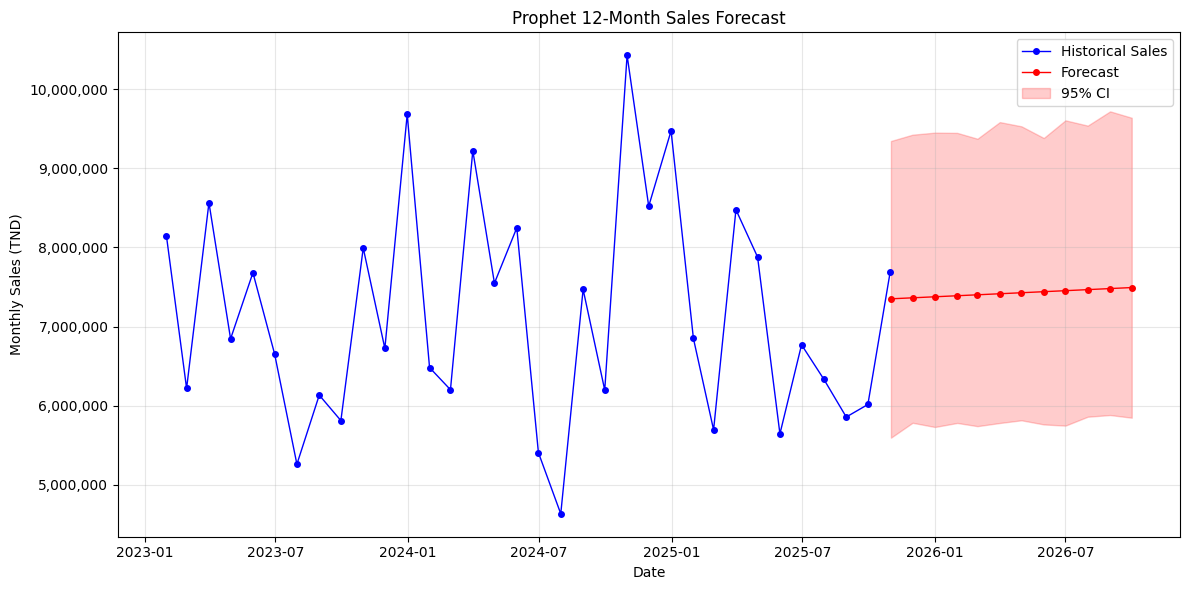

In [126]:
# Create future dataframe for next 12 months
future_12 = prophet_model.make_future_dataframe(periods=19, freq='MS')  # MS = Month Start

# Make predictions with confidence intervals
forecast_12 = prophet_model.predict(future_12)

# Get predictions for the next 12 months only
next_12_months = forecast_12.iloc[-12:].copy()

# Invert log transformation
next_12_months['Predicted_Profit'] = np.expm1(next_12_months['yhat'])
next_12_months['Lower_CI'] = np.expm1(next_12_months['yhat_lower'])
next_12_months['Upper_CI'] = np.expm1(next_12_months['yhat_upper'])

# Create final dataframe
prediction_df = next_12_months[['ds', 'Predicted_Profit', 'Lower_CI', 'Upper_CI']].copy()
prediction_df = prediction_df.rename(columns={'ds': 'Date'})

print("Next 12 Months Forecast:")
print(prediction_df.to_string())

# Plot the forecast
fig, ax = plt.subplots(figsize=(12, 6))

# Historical data
historical = df_prophet_all.copy()
historical['monthly_sales'] = np.expm1(historical['y'])  # Invert log transform

# Plot historical data
ax.plot(df_monthly_cf['month'], df_monthly_cf['monthly_sales'], 
        'bo-', label='Historical Sales', markersize=4, linewidth=1)

# Plot forecast
ax.plot(prediction_df['Date'], prediction_df['Predicted_Profit'], 
        'ro-', label='Forecast', markersize=4, linewidth=1)

# Plot confidence interval
ax.fill_between(prediction_df['Date'], 
                prediction_df['Lower_CI'], 
                prediction_df['Upper_CI'], 
                color='red', alpha=0.2, label='95% CI')

# Formatting
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Sales (TND)')
ax.set_title('Prophet 12-Month Sales Forecast')
ax.legend()
ax.grid(True, alpha=0.3)

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()